In [9]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict 
import subprocess
from openai import OpenAI

class State(TypedDict):
    video_file : str
    audio_file : str
    transcription : str

In [ ]:
# 노드 생성 

# 오디오 추출 (FFmpeg를 사용해서)
from openai.types.audio import transcription


def extract_audio(state : State):
    output_file = state["video_file"].replace("mp4","mp3") # mp4 -> mp3로 변환
    #ffmpeg - 이걸 이렇게 해주는 이유는 openai는 변환 작업에 대해 분당 요금을 받기 때문이다.  또한 오디오 파일의 속도를 빠르게 해서 변환해도 퀄리티가 떨어지지않음 (이로인해 변환비용 감소 )
    command = [
        "ffmpeg",
        "-i", 
        state["video_file"],
        "-filter:a",# 수정작업 
        "atempo=2.0" , #속도 임 2배 설정 
        "-y",  # ffmpeg에게 해당 파일을 덮어씌울 것인지 물어보면 yes라고 대답하도록 하는 코드  
        output_file
    ]
    subprocess.run(command)
    return{
        "audio_file" : output_file
    }

# 오디오 파일 변환 
def transcribe_audio(state : State):
    # use audio file 
    client = OpenAI()
    with open(state["audio_file"], "rb") as audio_file:
        transcription = client.audio.transcriptions.create(
            model = "whisper-1",
            response_format= "text",
            file = audio_file,
            language= "en", # 모델에게 영상이 어떤 언어로 되어있는지 알려주는것 , 모델에게 주는 힌트 
            prompt= "Netherlands, Rotterdam, Amsterdam, THe Hage" # gpt 프롬포트 같은게 아닌 모델에 단어 목록 같은 걸 주는 것임. (d이걸 주지 않으면 모델이 저 사람이 뭐라고 말하는지 알아내는게 힘들 수도있음, 모델이 듣게될 단어에 대한 힌트)
        )
        return{
            "transcription" : transcription
        }
def dispatch_summarizers(state : State):
    pass # 여기서 여러개의 send 커맨드를 분배 하고 

def summerize_chunk(id : int, chunk : str):   # id 값과 함께 이 chunk를 요약할 것임. 
    #chunk를 받을 노드 
    # send 명령어는 요약 노드들을 실행한다. 

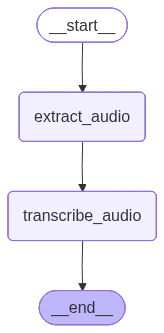

In [ ]:
# 그래프 생성 

graph_builder = StateGraph(State)

graph_builder.add_node("extract_audio",extract_audio)
graph_builder.add_node("transcribe_audio",transcribe_audio)
graph_builder.add_node("summerize_chunk",summerize_chunk)

graph_builder.add_edge(START, "extract_audio")
graph_builder.add_edge("extract_audio", "transcribe_audio")
graph_builder.add_conditional_edges("transcribe_audio", dispatch_summarizers , ["summerize_chunk"])

graph = graph_builder.compile()

graph

In [12]:
graph.invoke({"video_file": "netherlands.mp4"})

{'video_file': 'netherlands.mp4',
 'audio_file': 'netherlands.mp3',
 'transcription': "This episode is supported by Audible. Amazon Prime members can get an incredible 66% off their first 3 months at audible.com slash sui b h n e. Only available for a limited time, so sign up fast. Feudalism helped sway in the land, and as the trade increased, the cities of Amsterdam, Brugge, and Antwerpen prospered, and soon these trading posts became more and more integrated into the Hanseatic League, a sort of trade agreement in the North Sea after the Viking raids had ceased. Through both conquest and inheritance, the Dutch counties came under the control of the House of Burgundy, who then passed it on to the Austrian House of Habsburg. They pulled the Netherlands out of the Hanseatic League and then took over control of trade themselves. This is known as the Era of the Seventeen Provinces, but by this point the merchants had begun to embrace Calvinist Protestantism. This led to the Dutch Revolt, a

In [15]:
transcription = "This episode is supported by Audible. Amazon Prime members can get an incredible 66% off their first 3 months at audible.com slash sui b h n e. Only available for a limited time, so sign up fast. Feudalism helped sway in the land, and as the trade increased, the cities of Amsterdam, Brugge, and Antwerpen prospered, and soon these trading posts became more and more integrated into the Hanseatic League, a sort of trade agreement in the North Sea after the Viking raids had ceased. Through both conquest and inheritance, the Dutch counties came under the control of the House of Burgundy, who then passed it on to the Austrian House of Habsburg. They pulled the Netherlands out of the Hanseatic League and then took over control of trade themselves. This is known as the Era of the Seventeen Provinces, but by this point the merchants had begun to embrace Calvinist Protestantism. This led to the Dutch Revolt, also known as the Eighty Years' War, also known as the Dutch War for Independence. The war was a complex mix of secular, religious, and mercantile motives, but saw the Northern Provinces unite in the Treaty of Utrecht against the Spanish Union of Arras. The Spanish marched north, though, and managed to take back most of the south. In 1581, the United Provinces declared themselves free and independent, and the war became about securing that declaration. During the war, the Protestants in the south fled to the north, and the French Calvinists called the Huguenots followed suit, making Netherlands a firmly Protestant-controlled nation, and in 1588 became a confederated republic because they couldn't really find a good king. Instead, they instituted the Stadtholders with the House of Orange-Nassau, but only with the province's approval. The Dutch were very good at two things by this point – water and money. So, they combined them and formed the Verenigde Oostendische Compagnie to begin trade in the Indian Ocean. The Dutch Revolt overlapped with the broader Thirty Years' War, in which Spain was defeated and finally recognized as independent in the Peace of Westphalia. Jewish settlement increased, as the tolerance of the new republic was appealing to the persecuted Sephardic Jews, as well as growth in the small community of Ashkenazi Jews. The VOC brought immense wealth to the Dutch Republic, revolutionizing modern banking and finance. Dutch citizens enjoyed shares in the company, helping spread the wealth more evenly. This fueled the Dutch Golden Ages of art, architecture, and building of universities, making huge strides in science and medicine. The VOC dominated trade for half a century, founding trade colonies all over the world. It wasn't all rainbows and sunshine – the VOC operated with little to no oversight, and were often very violent, and engaged heavily in the slave trade. They eventually lost this dominance to the English, but their legacies as engineers and shipbuilders and financiers continued to spur growth. This became aggravated by Dutch merchants lending money to foreign powers, thereby protecting and growing their own wealth, which simultaneously stagnated the economy in the Netherlands while propping up foreign nations. But, you know, that's capitalism for you. The decline in prosperity and the devastating Anglo-Dutch Wars soon made them prime targets for... French revolutionaries overthrew the Dutch and created the Batavian Republic, then a monarchy under Napoleon's brother before final annexation into the French Empire, including the Southern Netherlands. When Napoleon was defeated, the Congress of Vienna created the United Kingdom of the Netherlands, merging with the Southern Netherlands to create a buffer state between France and the German states. William I of the House of Orange was made king. However, it was pretty short-lived because the Southern Netherlands was almost all Catholic, and the French language was far more important there. The South fought an independence war and broke away from the Dutch, forming the nation of Belgium. The Dutch returned to their economic ways and were decidedly neutral during the First World War. After the chaos died down, they found themselves battling Great Depression mostly by furthering trade with their colonies in Suriname and the Dutch East Indies. This was halted during the Second World War, in which the Netherlands was invaded to bypass the Maginot Line. The small country fell to the Germans and its Jewish population were deported and killed in the Holocaust. Rotterdam, the second largest city and major trade port, was firebombed and completely destroyed by the Luftwaffe. The Dutch East Indies was lost to Japan in 1942. Operation Market Garden was part of a larger strategy to cross the Rhine River to advance into the Northern Netherlands and Northern Germany, but it was deadlocked and they ultimately failed to capture the crossing at Arnhem in September of 1944. Instead, the troops would concentrate on Vessel and Rees on the Rhine to liberate the Netherlands, punching a deep hole through German territory and invading from the east. This incredible military achievement saw the greatest paratrooper landing in history, with more than 1.2 million allies involved, a massive success for the allies who were able to advance around the Dutch chokepoint. You can learn more about this real-world event in the incredible audiobook, Four Hours of Fury, by James M. Fennellen, for free for new members when you sign up for Audible, an extremely well-researched and well-documented narrative of the battle, for which he had a special interest as a paratrooper himself. And there is a special deal for Amazon Prime members. Until July 31, you can sign up for an Audible membership and get an incredible 66% off your first three months, basically getting three months for the price of one. New Audible members can listen to this book for free, or choose your own, in the vast library of fiction and non-fiction and copious amounts of history. And you even get one free audiobook and two Audible Originals per month for free, giving you more than ever with an Audible membership. Head to audible.com slash suibhne, or text suibhne to 500-500, and listen for free today with Audible. Thank you for watching. Please like and subscribe, and if you really enjoy the content, you can support on Patreon. Thank you.\n"

import textwrap

for i, chunk in enumerate(textwrap.wrap(transcription, 500)): # 500자씩 리스트로 나눔 
    print(f"Chunk ID : {i+1} : {chunk}")
    print("===")


Chunk ID : 1 : This episode is supported by Audible. Amazon Prime members can get an incredible 66% off their first 3 months at audible.com slash sui b h n e. Only available for a limited time, so sign up fast. Feudalism helped sway in the land, and as the trade increased, the cities of Amsterdam, Brugge, and Antwerpen prospered, and soon these trading posts became more and more integrated into the Hanseatic League, a sort of trade agreement in the North Sea after the Viking raids had ceased. Through both
===
Chunk ID : 2 : conquest and inheritance, the Dutch counties came under the control of the House of Burgundy, who then passed it on to the Austrian House of Habsburg. They pulled the Netherlands out of the Hanseatic League and then took over control of trade themselves. This is known as the Era of the Seventeen Provinces, but by this point the merchants had begun to embrace Calvinist Protestantism. This led to the Dutch Revolt, also known as the Eighty Years' War, also known as the